## Parse Data

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def list_to_plate(lst: pd.Series) -> pd.DataFrame:
    new_index = pd.MultiIndex.from_tuples([(i[0], int(i[1:])) for i in lst.index])
    plate =  pd.Series(lst.values, index=new_index).unstack()
    return plate

def plate_to_list(plate: pd.DataFrame) -> pd.Series:
    s = plate.stack()
    s.index = [f'{row}{col}' for row, col in s.index]
    return s

def set_plate_axes(df: pd.DataFrame) -> pd.DataFrame:
    """ Given a dataframe representing a multiwell plate, set axes to be proper plate axes. """

    df.columns = range(1, len(df.columns)+1)
    df.index = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'][:len(df.index)]
    return df

def bars(df, **kwargs):
    ax = sns.barplot(data=df,alpha=0.8, **kwargs)
    ax = sns.stripplot(data=df, ax=ax, size=6, dodge=True, legend=False,  edgecolor='black', linewidth=1, **kwargs)
    if 'hue' in kwargs.keys():
      plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    return ax


In [ ]:
df = df[~df.Sample.isin({'1117-44-00', '1076-08-00'})]


/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_97628/2808526705.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


[Text(0, 0, 'S2060 cryo #2'),
 Text(1, 0, 'S2060 cryo #4'),
 Text(2, 0, 'Positive Control')]

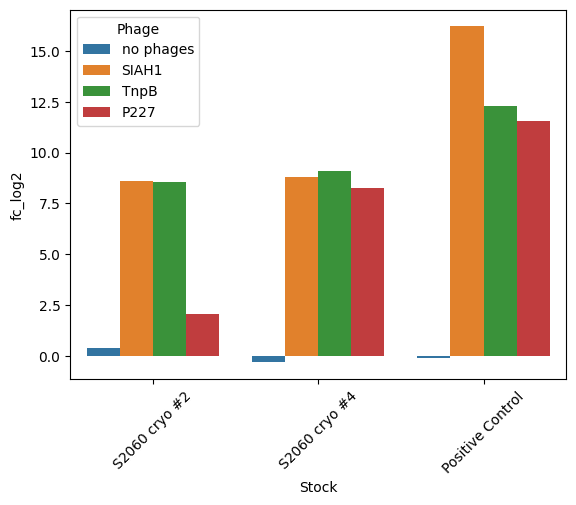

In [29]:

df = pd.read_excel('20240926_iDEC_other phages.xlsx')
df = df[['Cp avg', 'Stock', 'Phage']].dropna(subset=['Stock'])
df_ctrl = df[df.Stock == 'LB'].set_index('Phage')['Cp avg']
df = df[df.Stock != 'LB']

def calc_fc(row):
    return -row['Cp avg'] + df_ctrl.loc[row['Phage']]
    
df['fc_log2'] = df.apply(calc_fc, axis=1)
df.Stock = df.Stock.map(lambda x: {
    'S2060 old': 'S2060 cryo #1', 
    'S2060 cryo': 'S2060 cryo #2',
    'S2060 recent': 'S2060 cryo #3',
    'S2060 Lukas': 'S2060 cryo #4',
    'S2208': 'Positive Control',
    '-Control': 'Negative Control',
    }.get(x, x))

ax = sns.barplot(df, x='Stock', y='fc_log2', hue='Phage')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


In [28]:
df

,Cp avg,Stock,Phage,fc_log2
0,28.476667,S2060 cryo #2,no phages,0.393333
3,29.183333,S2060 cryo #4,no phages,-0.313333
6,28.973333,Positive Control,no phages,-0.103333
12,16.275000,S2060 cryo #2,SIAH1,8.605000
14,16.070000,S2060 cryo #4,SIAH1,8.810000
16,8.680000,Positive Control,SIAH1,16.200000
20,13.195000,S2060 cryo #2,TnpB,8.540000
22,12.625000,S2060 cryo #4,TnpB,9.110000
24,9.425000,Positive Control,TnpB,12.310000
28,19.815000,S2060 cryo #2,P227,2.045000


In [23]:
df

,Cp avg,Stock,Phage
0,28.476667,S2060 cryo,no phages
3,29.183333,S2060 Lukas,no phages
6,28.973333,S2208,no phages
12,16.275000,S2060 cryo,SIAH1
14,16.070000,S2060 Lukas,SIAH1
16,8.680000,S2208,SIAH1
20,13.195000,S2060 cryo,TnpB
22,12.625000,S2060 Lukas,TnpB
24,9.425000,S2208,TnpB
28,19.815000,S2060 cryo,P227


In [10]:
df

,Cp avg,Stock,Phage,phage titer
0,28.476667,S2060 cryo #2,no phages,1.976249e+04
3,29.183333,S2060 cryo #4,no phages,1.210916e+04
6,28.973333,Positive Control,no phages,1.400652e+04
9,28.870000,-Control,no phages,1.504654e+04
12,16.275000,S2060 cryo #2,SIAH1,9.309136e+07
14,16.070000,S2060 cryo #4,SIAH1,1.073051e+08
16,8.680000,Positive Control,SIAH1,1.799833e+10
18,24.880000,LB,SIAH1,2.390817e+05
20,13.195000,S2060 cryo #2,TnpB,7.871940e+08
22,12.625000,S2060 cryo #4,TnpB,1.168608e+09
